In [7]:
#Task4
#Q1
#importing the libraries
import pandas as pd
import numpy as np

pd.set_option("display.precision", 2)
pd.set_option("display.width", 100)

# load the dataset
df = pd.read_csv("students.csv")

#first 5 rows
print("--- First 5 rows ---")
print(df.head())

#shape and data types
print("\n--- Shape (rows x columns) ---")
print("Shape:", df.shape)
print("\n--- Data types ---")
print(df.dtypes)

#summary of the statistics for all numeric columns
print("\n--- Summary Statistics ---")
print(df.describe())

#counting students who passed and failed
print("\n--- Passed / Failed Count ---")
print(df["passed"].value_counts())

#calculating average score per subject for passing and failing students
subject_cols = ["math", "science", "english", "history", "pe"]

print("\n--- Average score per subject (Passed students) ---")
print(df[df["passed"] == 1][subject_cols].mean())

print("\n--- Average score per subject (Failed students) ---")
print(df[df["passed"] == 0][subject_cols].mean())

#student with the highest overall average across all 5 subjects
df["overall_avg"] = df[subject_cols].mean(axis=1)
top_student = df.loc[df["overall_avg"].idxmax(), "name"]
top_avg     = df["overall_avg"].max()

print(f"\n--- Student with Highest Overall Average ---")
print(f"{top_student} with an average of {top_avg:.2f}")

--- First 5 rows ---
      name  math  science  english  history  pe  attendance_pct  study_hours_per_day  passed
0    Alice    88       92       76       80  95              92                  4.5       1
1      Bob    42       55       48       50  60              65                  1.2       0
2  Charlie    75       70       80       68  88              85                  3.0       1
3    Diana    95       98       91       89  97              98                  6.0       1
4      Eve    38       42       50       45  55              58                  0.8       0

--- Shape (rows x columns) ---
Shape: (15, 9)

--- Data types ---
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics ---
        math  science  english  h

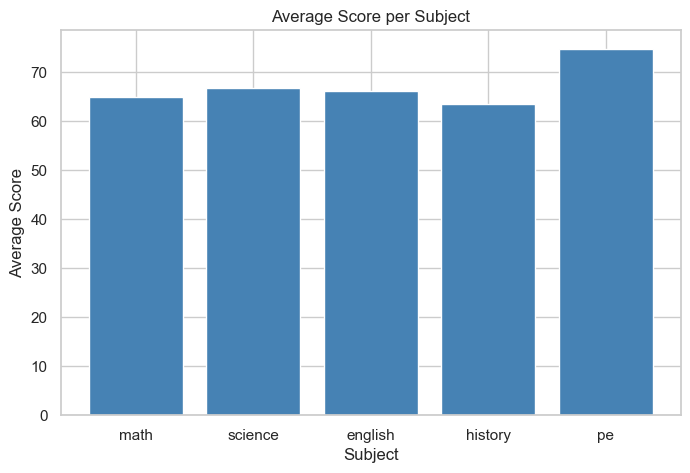

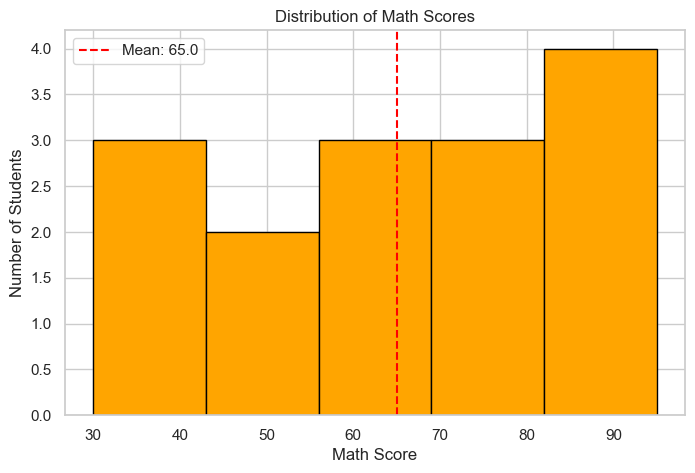

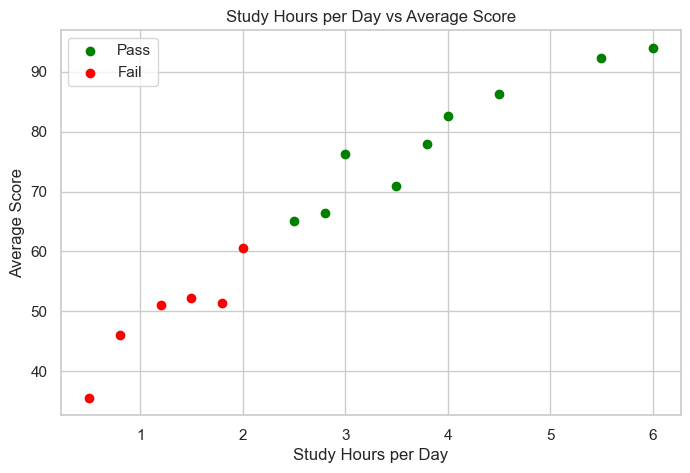

C:\Users\SPOORTHI\AppData\Local\Temp\ipykernel_27028\2765975249.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])


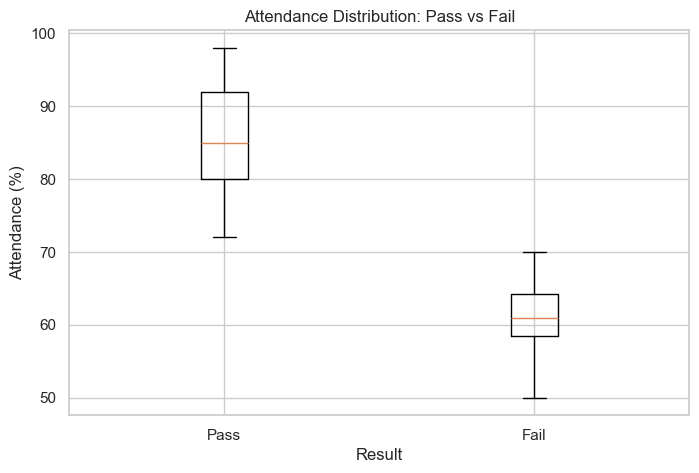

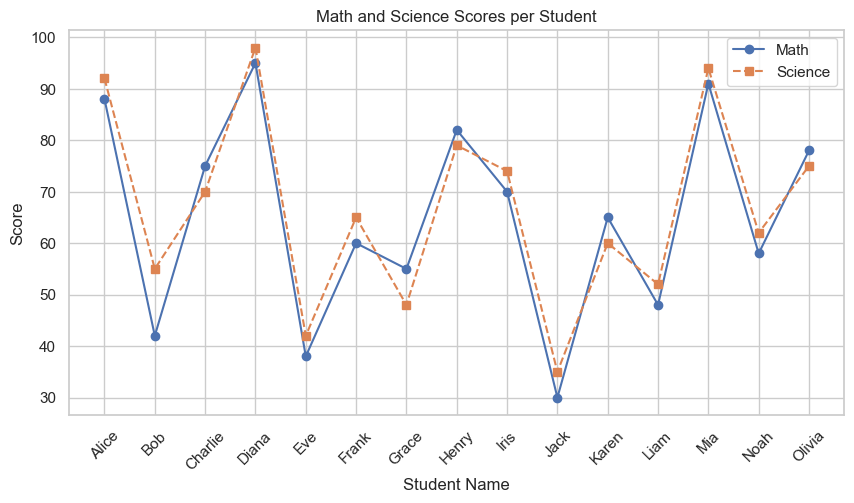

In [16]:
#Q2
import pandas as pd
import matplotlib.pyplot as plt

#load the dataset
df = pd.read_csv("students.csv")

# adding avg score column
subject_cols = ["math", "science", "english", "history", "pe"]
df["avg_score"] = df[subject_cols].mean(axis=1)


# Plot 1: Bar Chart — average score per subject 
avg_per_subject = df[subject_cols].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(avg_per_subject.index, avg_per_subject.values, color="steelblue")
ax.set_title("Average Score per Subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()


#  Plot 2: Histogram — distribution of math scores 
mean_math = df["math"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["math"], bins=5, color="orange", edgecolor="black")
ax.axvline(mean_math, color="red", linestyle="--", label=f"Mean: {mean_math:.1f}")
ax.set_title("Distribution of Math Scores")
ax.set_xlabel("Math Score")
ax.set_ylabel("Number of Students")
ax.legend()
plt.savefig("plot2_histogram.png")
plt.show()


#  Plot 3: Scatter Plot — study hours vs avg score 
pass_students = df[df["passed"] == 1]
fail_students = df[df["passed"] == 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pass_students["study_hours_per_day"], pass_students["avg_score"],
           color="green", label="Pass")
ax.scatter(fail_students["study_hours_per_day"], fail_students["avg_score"],
           color="red", label="Fail")
ax.set_title("Study Hours per Day vs Average Score")
ax.set_xlabel("Study Hours per Day")
ax.set_ylabel("Average Score")
ax.legend()
plt.savefig("plot3_scatter.png")
plt.show()


# Plot 4: Box Plot — attendance for pass vs fail 
pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])
ax.set_title("Attendance Distribution: Pass vs Fail")
ax.set_xlabel("Result")
ax.set_ylabel("Attendance (%)")
plt.savefig("plot4_boxplot.png")
plt.show()


#Plot 5: Line Plot — math and science scores per student
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["name"], df["math"],    marker="o", linestyle="-",  label="Math")
ax.plot(df["name"], df["science"], marker="s", linestyle="--", label="Science")
ax.set_title("Math and Science Scores per Student")
ax.set_xlabel("Student Name")
ax.set_ylabel("Score")
ax.legend()
plt.xticks(rotation=45)
plt.savefig("plot5_line.png")
plt.show()


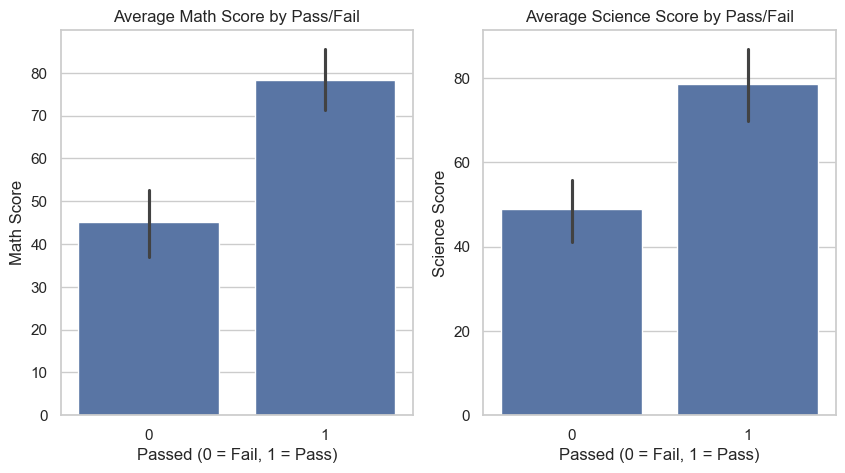

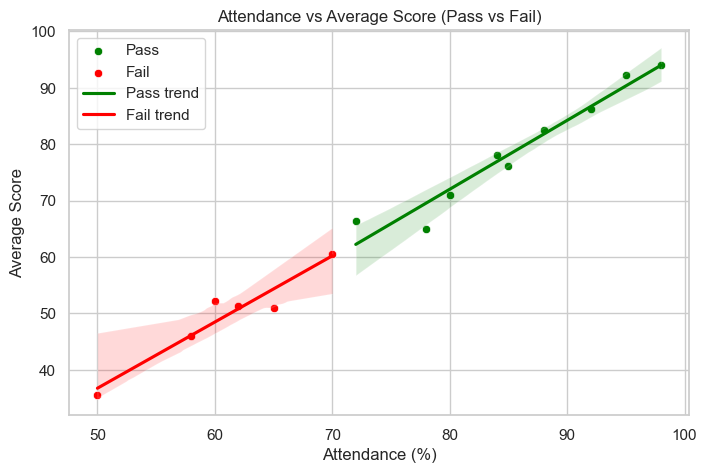

In [17]:
#Task3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# make sure avg_score column is there
subject_cols = ["math", "science", "english", "history", "pe"]
df["avg_score"] = df[subject_cols].mean(axis=1)


# ── Plot 1: Seaborn Bar Plot — avg math and science score by pass/fail ─────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=df, x="passed", y="math", ax=ax1)
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

sns.barplot(data=df, x="passed", y="science", ax=ax2)
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

plt.savefig("plot6_seaborn_bar.png")
plt.show()


# ── Plot 2: Seaborn Scatter Plot — attendance vs avg score with regression ─────
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df[df["passed"] == 1], x="attendance_pct", y="avg_score",
                color="green", label="Pass", ax=ax)
sns.scatterplot(data=df[df["passed"] == 0], x="attendance_pct", y="avg_score",
                color="red", label="Fail", ax=ax)

sns.regplot(data=df[df["passed"] == 1], x="attendance_pct", y="avg_score",
            scatter=False, color="green", label="Pass trend", ax=ax)
sns.regplot(data=df[df["passed"] == 0], x="attendance_pct", y="avg_score",
            scatter=False, color="red", label="Fail trend", ax=ax)

ax.set_title("Attendance vs Average Score (Pass vs Fail)")
ax.set_xlabel("Attendance (%)")
ax.set_ylabel("Average Score")
ax.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# ── Seaborn vs Matplotlib comparison ──────────────────────────────────────────
# Seaborn was easier to use compared to Matplotlib for these plots.
# sns.barplot() automatically calculated the group averages without me having
# to do it manually first, and sns.regplot() added the regression line in just
# one line which would have taken a lot more code in Matplotlib.

In [3]:
!pip3 install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.datasets import make_classification, make_regression

In [13]:
# TASK 4
# STEP 1
# load the dataset
df = pd.read_csv("students.csv")

# step 1 - separate features and target
# only exclude 'name' and 'passed' from X, keep df intact
X = df[["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]]
y = df["passed"]

# step 2 - split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

# step 3 - scale features using StandardScaler
# fit on training data only, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")
print("X_train_scaled mean (should be ~0):", X_train_scaled.mean(axis=0).round(2))

X_train shape: (12, 7)
X_test shape:  (3, 7)
Scaling done.
X_train_scaled mean (should be ~0): [-0.  0. -0. -0.  0.  0. -0.]


In [23]:
# step 2 - train the model
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)

# print training accuracy
train_preds = model.predict(X_train_scaled)
print(f"Training accuracy: {accuracy_score(y_train, train_preds):.4f}")

# step 3 - predict on test data
preds = model.predict(X_test_scaled)

# print test accuracy
acc = accuracy_score(y_test, preds)
print(f"Test accuracy: {acc:.4f}")

# print each student name, actual label, predicted label, and result
print("\nStudent predictions:")
names = df.loc[X_test.index, "name"]

for n, a, p in zip(names, y_test, preds):
    if a == p:
        res = "correct"
    else:
        res = "wrong"
    print(f"{n:<10}  actual: {a}  predicted: {p}  {res}")

Training accuracy: 1.0000
Test accuracy: 1.0000

Student predictions:
Jack        actual: 0  predicted: 0  correct
Liam        actual: 0  predicted: 0  correct
Alice       actual: 1  predicted: 1  correct


Feature Coefficients (sorted by importance):
  english                   0.8125
  attendance_pct            0.5219
  study_hours_per_day       0.4844
  pe                        0.4750
  math                      0.4379
  science                   0.3230
  history                   0.2629


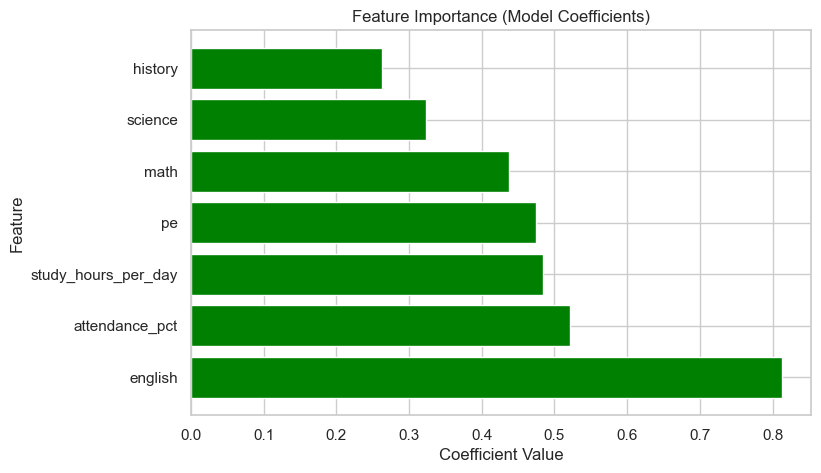

In [26]:
# step 4 
coefficients = model.coef_[0]
feature_names = ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]

#pair each feature name with its coefficient and sort 
feature_coef = list(zip(feature_names, coefficients))
feature_coef.sort(key=lambda x: abs(x[1]), reverse=True)

# printing the sorted coefficients
print("Feature Coefficients (sorted by importance):")
for name, coef in feature_coef:
    print(f"  {name:<25} {coef:.4f}")

#creating a horizontal bar chart
names_sorted  = [x[0] for x in feature_coef]
values_sorted = [x[1] for x in feature_coef]

#green for positive coefficients and red for negative
colors = ["green" if v > 0 else "red" for v in values_sorted]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(names_sorted, values_sorted, color=colors)
ax.set_title("Feature Importance (Model Coefficients)")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")
plt.show()

In [25]:
#step 5
#define a new student
feature_names = ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]
new_student = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=feature_names)

# scale and predictting
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)

if prediction[0] == 1:
    result = "Pass"
else:
    result = "Fail"

print(f"Prediction for new student: {result}")

Prediction for new student: Pass
